# NLP Preprocessing Comparison: NLTK vs SpaCy
Processing song lyrics with tokenization, stemming, and lemmatization

NLP Text Preprocessing: NLTK vs SpaCy
Processing: 'Escape (The Piña Colada Song)' lyrics

Loaded text: 1962 characters

NLTK PREPROCESSING

1. Sentence Tokenization:
   - Total sentences: 1
   - First 3 sentences:
     1. "Escape (The Piña Colada Song)" by Rupert Holmes

[Verse 1]
I was tired of my la...

2. Word Tokenization:
   - Total tokens: 461
   - Sample tokens: ['``', 'escape', '(', 'the', 'piña', 'colada', 'song', ')', "''", 'by', 'rupert', 'holmes', '[', 'verse', '1', ']', 'i', 'was', 'tired', 'of']
   - Alphabetic tokens only: 390
   - Sample: ['escape', 'the', 'piña', 'colada', 'song', 'by', 'rupert', 'holmes', 'verse', 'i', 'was', 'tired', 'of', 'my', 'lady']

3. Part-of-Speech Tagging:
   - Sample POS tags:
     'escape' -> VB
     'the' -> DT
     'piña' -> NN
     'colada' -> NN
     'song' -> NN
     'by' -> IN
     'rupert' -> NN
     'holmes' -> NNS
     'verse' -> VBP
     'i' -> NN

4. Stemming:
   Porter Stemmer examples:
     'escape' -> 'escap'
     'holmes' -> 

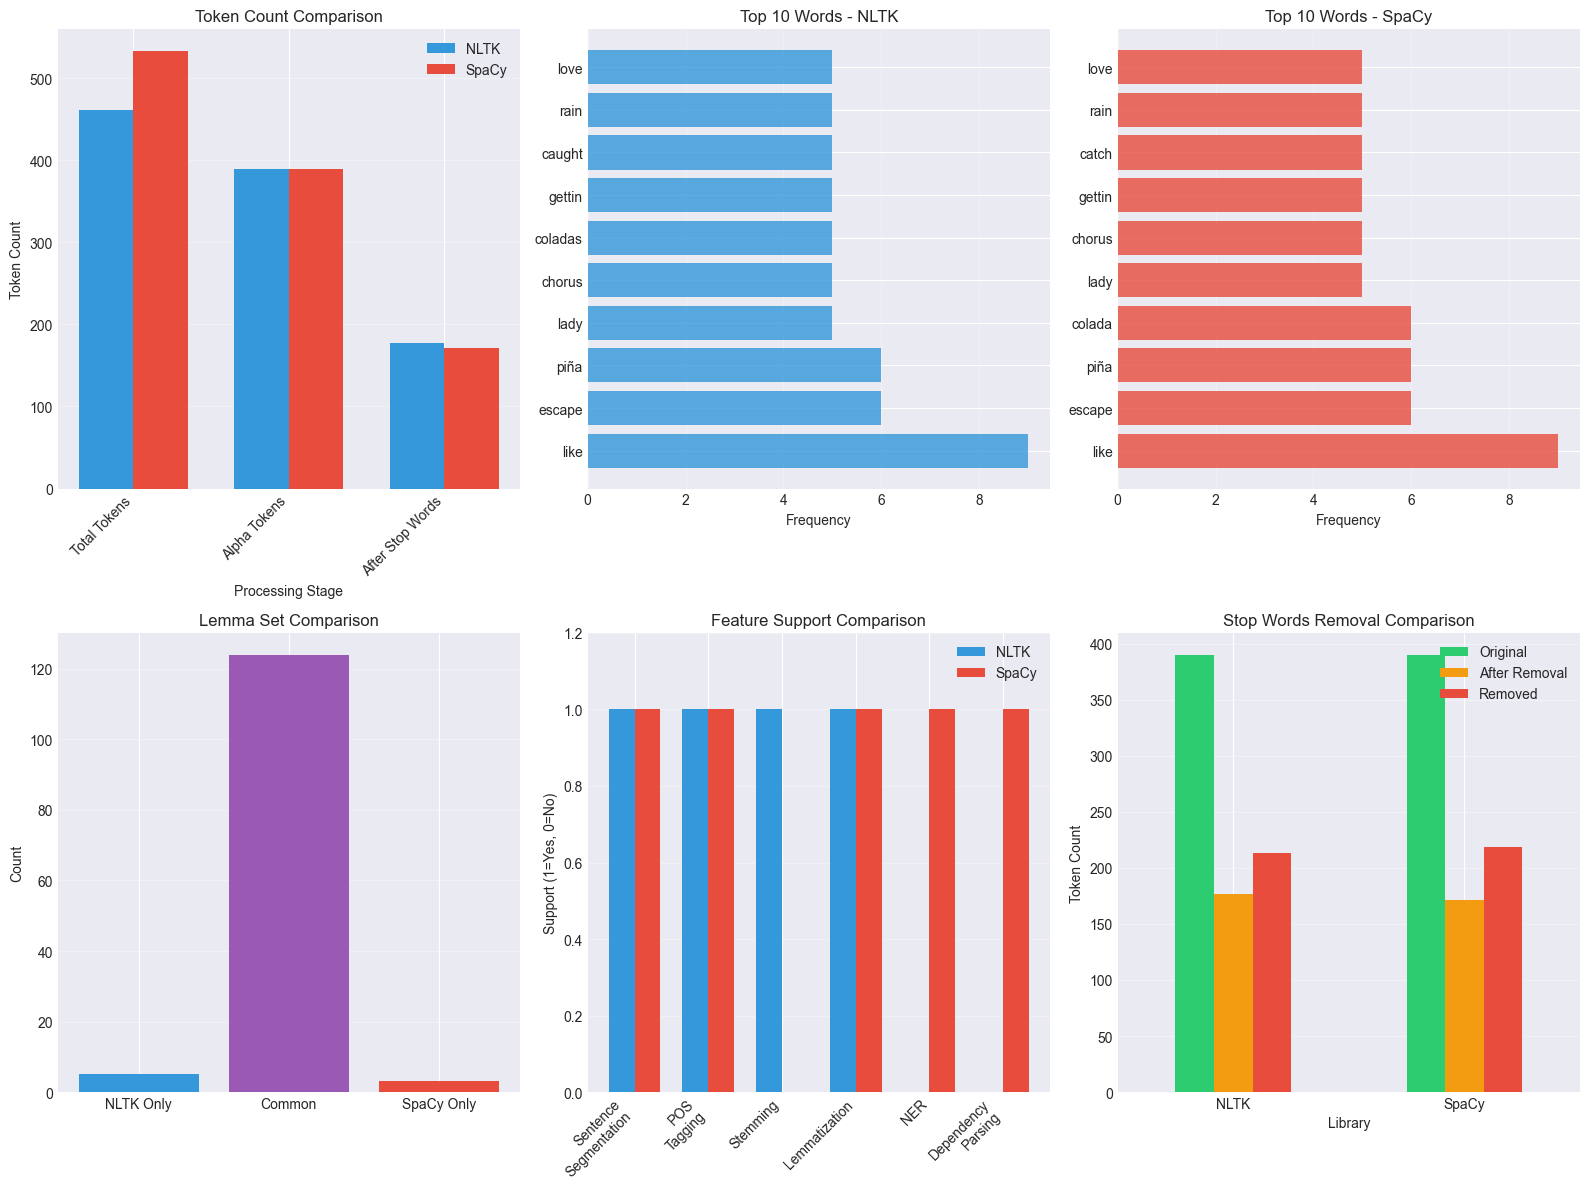


1. Sentence Segmentation:
   - Total sentences: 20
   - First 3 sentences:
     1. "Escape (The Piña Colada Song)" by Rupert Holmes...
     2. [Verse 1]
I was tired of my lady
We'd been together too long
Like a worn out rec...
     3. So while she lay there sleeping
I read the paper in bed
And in the personal colu...

2. Tokenization:
   - Total tokens: 533
   - Alphabetic tokens: 390
   - Sample tokens: ['escape', 'the', 'piña', 'colada', 'song', 'by', 'rupert', 'holmes', 'verse', 'i', 'was', 'tired', 'of', 'my', 'lady']

3. Part-of-Speech Tagging:
   - Sample POS tags (word, POS, detailed tag):
     'Escape' -> PROPN (NNP)
     'The' -> DET (DT)
     'Piña' -> PROPN (NNP)
     'Colada' -> PROPN (NNP)
     'Song' -> PROPN (NNP)
     'by' -> ADP (IN)
     'Rupert' -> PROPN (NNP)
     'Holmes' -> PROPN (NNP)
     'Verse' -> PROPN (NNP)
     'I' -> PRON (PRP)

4. Lemmatization:
   - Lemmatization examples:
     'was' -> 'be'
     'been' -> 'be'
     'worn' -> 'wear'
     'lay' -> 'lie'



📊 Saving JSON results...
📊 JSON results saved to: nlp_comparison_results.json

📄 Generating detailed HTML report...

📄 HTML report saved to: nlp_comparison_report.html

PROCESSING COMPLETE

✅ All reports generated successfully!

📁 Output files in current directory:
   • nlp_comparison_charts.png - Visual comparisons
   • nlp_comparison_report.html - Detailed HTML report
   • nlp_comparison_results.json - Structured data

🎯 Key Findings:
1. SpaCy excels at sentence segmentation (20 vs 1 sentences)
2. SpaCy provides more accurate lemmatization
3. NLTK offers unique stemming algorithms
4. SpaCy includes NER and dependency parsing
5. Both libraries have similar tokenization performance

💡 Open nlp_comparison_report.html in a browser for the full analysis!


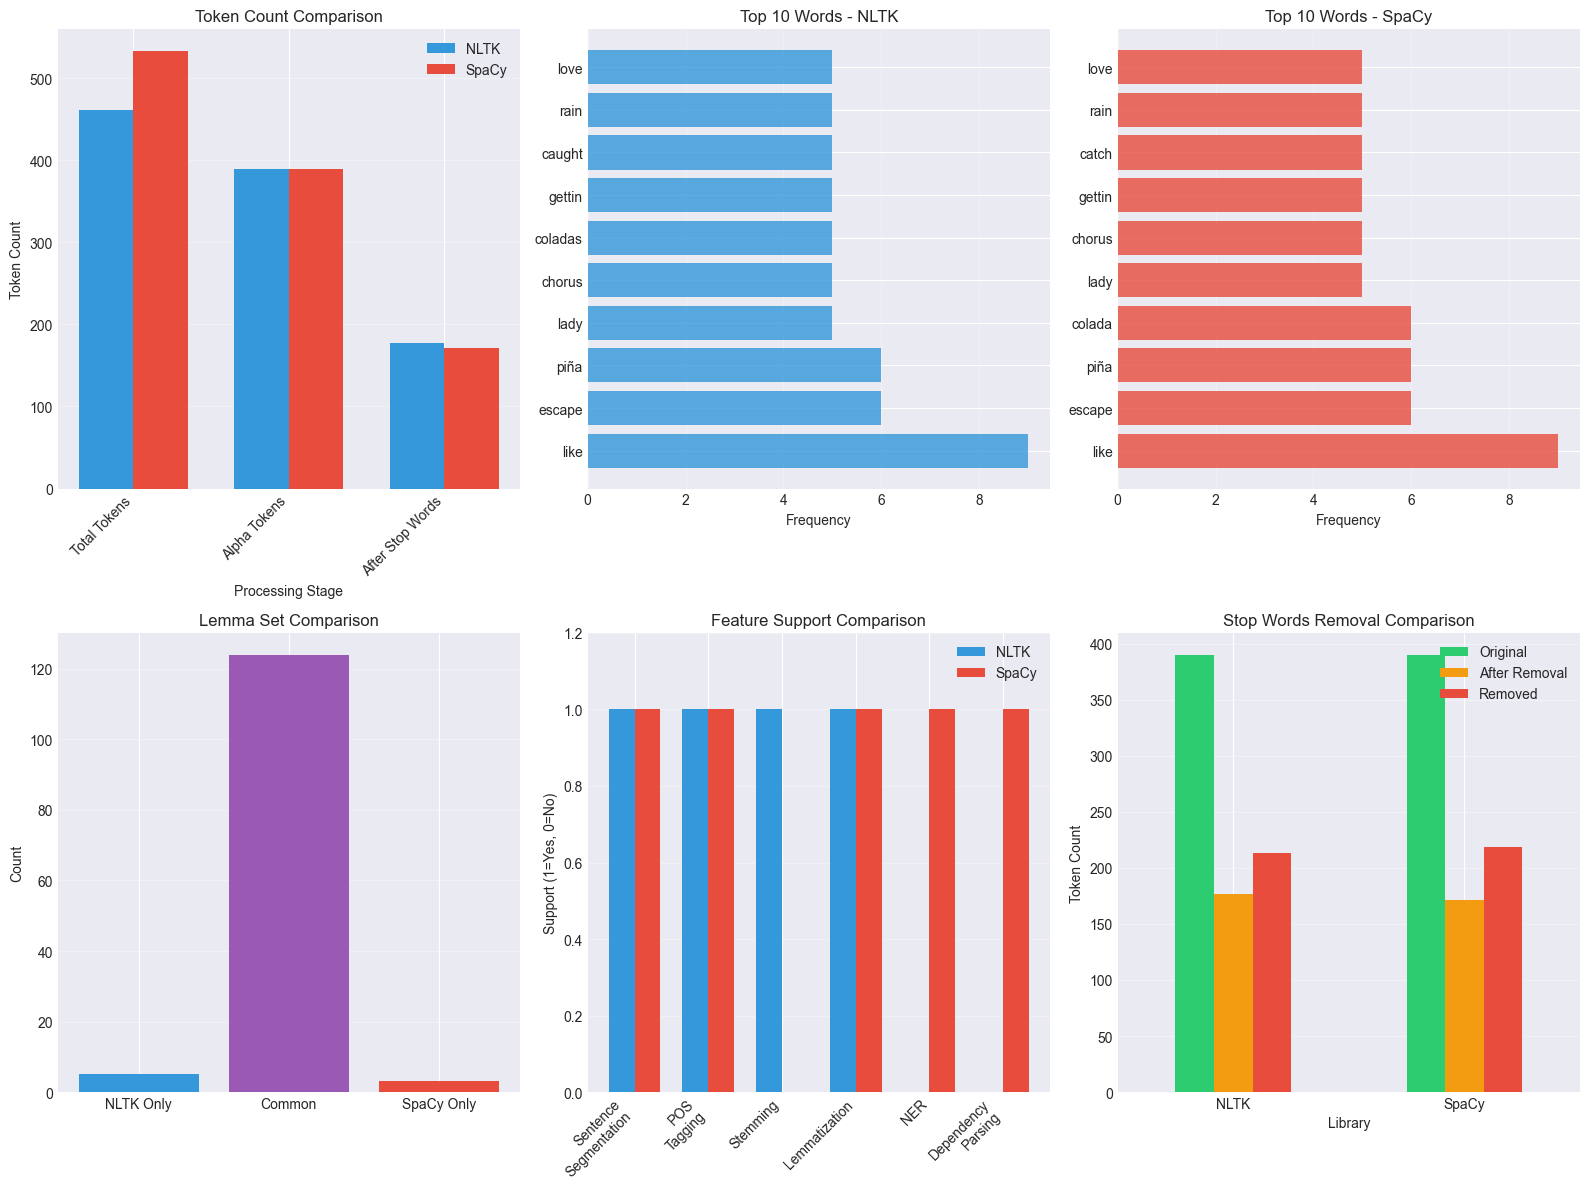

In [1]:
#!/usr/bin/env python3
"""
NLP Preprocessing Comparison: NLTK vs SpaCy
Processing song lyrics with tokenization, stemming, and lemmatization
"""

import os
import sys
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
from nltk import pos_tag

import spacy
from spacy.lang.en.stop_words import STOP_WORDS

from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json


# Configuration Constants
class Config:
    """Configuration constants for NLP preprocessing"""
    # Display limits
    MAX_DISPLAY_EXAMPLES = 10
    MAX_SENTENCE_DISPLAY = 3
    SENTENCE_PREVIEW_LENGTH = 80
    TOKEN_SAMPLE_SIZE = 20
    ALPHA_TOKEN_SAMPLE = 15

    # Analysis parameters
    TOP_N_WORDS = 10
    TOP_N_WORDS_REPORT = 15
    DETAILED_COMPARISON_WORDS = 20
    SAMPLE_WORDS_LIMIT = 50

    # Word samples for comparison
    SAMPLE_WORDS = ['like', 'caught', 'making', 'escape', 'lady', 'written', 'sleeping']

    # Visualization settings
    CHART_FIGSIZE = (16, 12)
    CHART_DPI = 150
    CHART_BAR_WIDTH = 0.35
    CHART_GRID_ALPHA = 0.3
    CHART_BAR_ALPHA = 0.8

    # Style colors
    COLOR_NLTK = '#3498db'
    COLOR_SPACY = '#e74c3c'
    COLOR_COMMON = '#9b59b6'
    COLOR_SUCCESS = '#2ecc71'
    COLOR_WARNING = '#f39c12'


def setup_nltk():
    """Download required NLTK data packages"""
    required_packages = [
        'punkt', 'averaged_perceptron_tagger', 'wordnet',
        'omw-1.4', 'stopwords', 'punkt_tab'
    ]

    failed_packages = []
    for package in required_packages:
        try:
            nltk.data.find(f'tokenizers/{package}')
        except LookupError:
            try:
                print(f"Downloading NLTK package: {package}")
                nltk.download(package, quiet=True)
            except (OSError, IOError, Exception) as e:
                failed_packages.append((package, str(e)))
                print(f"Warning: Failed to download {package}: {e}")

    if failed_packages:
        print(f"Warning: Some NLTK packages failed to download: {failed_packages}")


def load_text(filepath):
    """Load text from file"""
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    return text


def get_wordnet_pos(treebank_tag):
    """Convert Penn Treebank POS tags to WordNet POS tags"""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


def nltk_preprocessing(text):
    """
    Preprocess text using NLTK
    Includes: tokenization, POS tagging, stemming, and lemmatization
    """
    print("\n" + "="*60)
    print("NLTK PREPROCESSING")
    print("="*60)

    # Sentence tokenization
    sentences = sent_tokenize(text)
    print(f"\n1. Sentence Tokenization:")
    print(f"   - Total sentences: {len(sentences)}")
    print(f"   - First {Config.MAX_SENTENCE_DISPLAY} sentences:")
    for i, sent in enumerate(sentences[:Config.MAX_SENTENCE_DISPLAY], 1):
        print(f"     {i}. {sent[:Config.SENTENCE_PREVIEW_LENGTH]}...")

    # Word tokenization
    tokens = word_tokenize(text.lower())
    print(f"\n2. Word Tokenization:")
    print(f"   - Total tokens: {len(tokens)}")
    print(f"   - Sample tokens: {tokens[:Config.TOKEN_SAMPLE_SIZE]}")

    # Remove punctuation and get alphabetic tokens only
    alpha_tokens = [token for token in tokens if token.isalpha()]
    print(f"   - Alphabetic tokens only: {len(alpha_tokens)}")
    print(f"   - Sample: {alpha_tokens[:Config.ALPHA_TOKEN_SAMPLE]}")

    # POS Tagging
    pos_tagged = pos_tag(alpha_tokens)
    print(f"\n3. Part-of-Speech Tagging:")
    print(f"   - Sample POS tags:")
    for word, pos in pos_tagged[:Config.MAX_DISPLAY_EXAMPLES]:
        print(f"     '{word}' -> {pos}")

    # Stemming (Porter and Snowball)
    porter = PorterStemmer()
    snowball = SnowballStemmer('english')

    porter_stems = [porter.stem(token) for token in alpha_tokens]
    snowball_stems = [snowball.stem(token) for token in alpha_tokens]

    print(f"\n4. Stemming:")
    print(f"   Porter Stemmer examples:")
    for i in range(min(Config.MAX_DISPLAY_EXAMPLES, len(alpha_tokens))):
        if alpha_tokens[i] != porter_stems[i]:
            print(f"     '{alpha_tokens[i]}' -> '{porter_stems[i]}'")

    print(f"\n   Snowball Stemmer examples:")
    for i in range(min(Config.MAX_DISPLAY_EXAMPLES, len(alpha_tokens))):
        if alpha_tokens[i] != snowball_stems[i]:
            print(f"     '{alpha_tokens[i]}' -> '{snowball_stems[i]}'")

    # Lemmatization
    lemmatizer = WordNetLemmatizer()

    # Simple lemmatization (assuming all nouns)
    simple_lemmas = [lemmatizer.lemmatize(token) for token in alpha_tokens]

    # POS-aware lemmatization
    pos_aware_lemmas = []
    for token, pos in pos_tagged:
        wordnet_pos = get_wordnet_pos(pos)
        lemma = lemmatizer.lemmatize(token, pos=wordnet_pos)
        pos_aware_lemmas.append(lemma)

    print(f"\n5. Lemmatization:")
    print(f"   Simple lemmatization examples:")
    for i in range(min(Config.MAX_DISPLAY_EXAMPLES, len(alpha_tokens))):
        if alpha_tokens[i] != simple_lemmas[i]:
            print(f"     '{alpha_tokens[i]}' -> '{simple_lemmas[i]}'")

    print(f"\n   POS-aware lemmatization examples:")
    for i in range(min(Config.MAX_DISPLAY_EXAMPLES, len(alpha_tokens))):
        if alpha_tokens[i] != pos_aware_lemmas[i]:
            print(f"     '{alpha_tokens[i]}' -> '{pos_aware_lemmas[i]}'")

    # Stop words removal
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [token for token in alpha_tokens if token not in stop_words]
    filtered_lemmas = [lemma for lemma in pos_aware_lemmas if lemma not in stop_words]

    print(f"\n6. Stop Words Removal:")
    print(f"   - Original tokens: {len(alpha_tokens)}")
    print(f"   - After stop word removal: {len(filtered_tokens)}")
    print(f"   - Removed {len(alpha_tokens) - len(filtered_tokens)} stop words")

    return {
        'sentences': sentences,
        'tokens': tokens,
        'alpha_tokens': alpha_tokens,
        'pos_tags': pos_tagged,
        'porter_stems': porter_stems,
        'snowball_stems': snowball_stems,
        'simple_lemmas': simple_lemmas,
        'pos_aware_lemmas': pos_aware_lemmas,
        'filtered_tokens': filtered_tokens,
        'filtered_lemmas': filtered_lemmas
    }


def spacy_preprocessing(text):
    """
    Preprocess text using SpaCy
    Includes: tokenization, POS tagging, lemmatization, NER
    """
    print("\n" + "="*60)
    print("SPACY PREPROCESSING")
    print("="*60)

    # Load SpaCy model
    try:
        nlp = spacy.load("en_core_web_sm")
    except (OSError, ImportError) as e:
        print(f"SpaCy model not found: {e}. Installing...")
        try:
            os.system("python -m spacy download en_core_web_sm")
            nlp = spacy.load("en_core_web_sm")
        except Exception as e:
            print(f"Error loading SpaCy model: {e}")
            raise

    # Process text
    doc = nlp(text)

    # Sentence segmentation
    sentences = [sent.text.strip() for sent in doc.sents]
    print(f"\n1. Sentence Segmentation:")
    print(f"   - Total sentences: {len(sentences)}")
    print(f"   - First {Config.MAX_SENTENCE_DISPLAY} sentences:")
    for i, sent in enumerate(sentences[:Config.MAX_SENTENCE_DISPLAY], 1):
        print(f"     {i}. {sent[:Config.SENTENCE_PREVIEW_LENGTH]}...")

    # Tokenization
    tokens = [token.text for token in doc]
    alpha_tokens = [token.text.lower() for token in doc if token.is_alpha]

    print(f"\n2. Tokenization:")
    print(f"   - Total tokens: {len(tokens)}")
    print(f"   - Alphabetic tokens: {len(alpha_tokens)}")
    print(f"   - Sample tokens: {alpha_tokens[:Config.ALPHA_TOKEN_SAMPLE]}")

    # POS Tagging
    pos_tags = [(token.text, token.pos_, token.tag_) for token in doc if token.is_alpha]
    print(f"\n3. Part-of-Speech Tagging:")
    print(f"   - Sample POS tags (word, POS, detailed tag):")
    for word, pos, tag in pos_tags[:Config.MAX_DISPLAY_EXAMPLES]:
        print(f"     '{word}' -> {pos} ({tag})")

    # Lemmatization - Optimized with single pass
    lemmas = [token.lemma_.lower() for token in doc if token.is_alpha]
    print(f"\n4. Lemmatization:")
    print(f"   - Lemmatization examples:")

    # Collect lemmatization examples in single pass
    lemma_examples = [(token.text, token.lemma_)
                     for token in doc
                     if token.is_alpha and token.text.lower() != token.lemma_.lower()]

    # Display limited examples
    for text, lemma in lemma_examples[:Config.MAX_DISPLAY_EXAMPLES]:
        print(f"     '{text}' -> '{lemma}'")

    # Named Entity Recognition
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    print(f"\n5. Named Entity Recognition:")
    if entities:
        print(f"   - Found {len(entities)} entities:")
        for text, label in entities:
            print(f"     '{text}' -> {label}")
    else:
        print("   - No named entities found")

    # Dependency parsing sample
    print(f"\n6. Dependency Parsing (first sentence):")
    first_sent = list(doc.sents)[0]
    for token in first_sent:
        if token.dep_ != "punct":
            print(f"   - '{token.text}' <- {token.dep_} <- '{token.head.text}'")

    # Stop words removal
    filtered_tokens = [token.text.lower() for token in doc
                      if token.is_alpha and token.text.lower() not in STOP_WORDS]
    filtered_lemmas = [token.lemma_.lower() for token in doc
                      if token.is_alpha and token.lemma_.lower() not in STOP_WORDS]

    print(f"\n7. Stop Words Removal:")
    print(f"   - Original tokens: {len(alpha_tokens)}")
    print(f"   - After stop word removal: {len(filtered_tokens)}")
    print(f"   - Removed {len(alpha_tokens) - len(filtered_tokens)} stop words")

    return {
        'doc': doc,
        'sentences': sentences,
        'tokens': tokens,
        'alpha_tokens': alpha_tokens,
        'pos_tags': pos_tags,
        'lemmas': lemmas,
        'entities': entities,
        'filtered_tokens': filtered_tokens,
        'filtered_lemmas': filtered_lemmas
    }


def compare_results(nltk_results, spacy_results):
    """Compare NLTK and SpaCy preprocessing results"""
    print("\n" + "="*60)
    print("COMPARISON: NLTK vs SPACY")
    print("="*60)

    # Token comparison
    nltk_tokens_set = set(nltk_results['alpha_tokens'])
    spacy_tokens_set = set(spacy_results['alpha_tokens'])

    print("\n1. Tokenization Comparison:")
    print(f"   - NLTK tokens: {len(nltk_results['alpha_tokens'])}")
    print(f"   - SpaCy tokens: {len(spacy_results['alpha_tokens'])}")
    print(f"   - Common tokens: {len(nltk_tokens_set & spacy_tokens_set)}")
    print(f"   - NLTK-only tokens: {nltk_tokens_set - spacy_tokens_set}")
    print(f"   - SpaCy-only tokens: {spacy_tokens_set - nltk_tokens_set}")

    # Lemmatization comparison
    nltk_lemmas_set = set(nltk_results['pos_aware_lemmas'])
    spacy_lemmas_set = set(spacy_results['lemmas'])

    print("\n2. Lemmatization Comparison:")
    print(f"   - NLTK lemmas (unique): {len(nltk_lemmas_set)}")
    print(f"   - SpaCy lemmas (unique): {len(spacy_lemmas_set)}")
    print(f"   - Common lemmas: {len(nltk_lemmas_set & spacy_lemmas_set)}")

    # Word frequency analysis
    print("\n3. Most Common Words (after preprocessing):")

    nltk_freq = Counter(nltk_results['filtered_lemmas'])
    spacy_freq = Counter(spacy_results['filtered_lemmas'])

    print(f"\n   NLTK Top {Config.TOP_N_WORDS} words:")
    for word, count in nltk_freq.most_common(Config.TOP_N_WORDS):
        print(f"     '{word}': {count}")

    print(f"\n   SpaCy Top {Config.TOP_N_WORDS} words:")
    for word, count in spacy_freq.most_common(Config.TOP_N_WORDS):
        print(f"     '{word}': {count}")

    # Create comparison DataFrame
    comparison_data = []
    sample_words = Config.SAMPLE_WORDS

    for word in sample_words:
        word_lower = word.lower()
        if word_lower in nltk_results['alpha_tokens']:
            idx = nltk_results['alpha_tokens'].index(word_lower)
            nltk_stem_p = nltk_results['porter_stems'][idx] if idx < len(nltk_results['porter_stems']) else 'N/A'
            nltk_stem_s = nltk_results['snowball_stems'][idx] if idx < len(nltk_results['snowball_stems']) else 'N/A'
            nltk_lemma = nltk_results['pos_aware_lemmas'][idx] if idx < len(nltk_results['pos_aware_lemmas']) else 'N/A'
        else:
            nltk_stem_p = nltk_stem_s = nltk_lemma = 'N/A'

        # Find SpaCy lemma
        spacy_lemma = 'N/A'
        for token in spacy_results['doc']:
            if token.text.lower() == word_lower:
                spacy_lemma = token.lemma_.lower()
                break

        comparison_data.append({
            'Word': word,
            'NLTK Porter Stem': nltk_stem_p,
            'NLTK Snowball Stem': nltk_stem_s,
            'NLTK Lemma': nltk_lemma,
            'SpaCy Lemma': spacy_lemma
        })

    df = pd.DataFrame(comparison_data)
    print("\n4. Sample Word Processing Comparison:")
    print(df.to_string(index=False))

    return df


def generate_visualizations(nltk_results, spacy_results):
    """Generate charts and visualizations for the report"""

    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")

    # Create figure with subplots
    fig = plt.figure(figsize=Config.CHART_FIGSIZE)

    # 1. Token Count Comparison
    ax1 = plt.subplot(2, 3, 1)
    categories = ['Total Tokens', 'Alpha Tokens', 'After Stop Words']
    nltk_counts = [len(nltk_results['tokens']),
                   len(nltk_results['alpha_tokens']),
                   len(nltk_results['filtered_tokens'])]
    spacy_counts = [len(spacy_results['tokens']),
                    len(spacy_results['alpha_tokens']),
                    len(spacy_results['filtered_tokens'])]

    x = range(len(categories))
    width = Config.CHART_BAR_WIDTH
    ax1.bar([i - width/2 for i in x], nltk_counts, width, label='NLTK', color=Config.COLOR_NLTK)
    ax1.bar([i + width/2 for i in x], spacy_counts, width, label='SpaCy', color=Config.COLOR_SPACY)
    ax1.set_xlabel('Processing Stage')
    ax1.set_ylabel('Token Count')
    ax1.set_title('Token Count Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=Config.CHART_GRID_ALPHA)

    # 2. Word Frequency Distribution
    ax2 = plt.subplot(2, 3, 2)
    nltk_freq = Counter(nltk_results['filtered_lemmas'])
    spacy_freq = Counter(spacy_results['filtered_lemmas'])

    nltk_top = nltk_freq.most_common(Config.TOP_N_WORDS)
    spacy_top = spacy_freq.most_common(Config.TOP_N_WORDS)

    words_nltk = [w[0] for w in nltk_top]
    counts_nltk = [w[1] for w in nltk_top]

    ax2.barh(range(len(words_nltk)), counts_nltk, color=Config.COLOR_NLTK, alpha=Config.CHART_BAR_ALPHA)
    ax2.set_yticks(range(len(words_nltk)))
    ax2.set_yticklabels(words_nltk)
    ax2.set_xlabel('Frequency')
    ax2.set_title(f'Top {Config.TOP_N_WORDS} Words - NLTK')
    ax2.grid(axis='x', alpha=Config.CHART_GRID_ALPHA)

    # 3. SpaCy Word Frequency
    ax3 = plt.subplot(2, 3, 3)
    words_spacy = [w[0] for w in spacy_top]
    counts_spacy = [w[1] for w in spacy_top]

    ax3.barh(range(len(words_spacy)), counts_spacy, color=Config.COLOR_SPACY, alpha=Config.CHART_BAR_ALPHA)
    ax3.set_yticks(range(len(words_spacy)))
    ax3.set_yticklabels(words_spacy)
    ax3.set_xlabel('Frequency')
    ax3.set_title(f'Top {Config.TOP_N_WORDS} Words - SpaCy')
    ax3.grid(axis='x', alpha=Config.CHART_GRID_ALPHA)

    # 4. Unique Lemmas Comparison
    ax4 = plt.subplot(2, 3, 4)
    nltk_lemmas_set = set(nltk_results['pos_aware_lemmas'])
    spacy_lemmas_set = set(spacy_results['lemmas'])

    venn_data = {
        'NLTK Only': len(nltk_lemmas_set - spacy_lemmas_set),
        'Common': len(nltk_lemmas_set & spacy_lemmas_set),
        'SpaCy Only': len(spacy_lemmas_set - nltk_lemmas_set)
    }

    colors = [Config.COLOR_NLTK, Config.COLOR_COMMON, Config.COLOR_SPACY]
    ax4.bar(venn_data.keys(), venn_data.values(), color=colors)
    ax4.set_ylabel('Count')
    ax4.set_title('Lemma Set Comparison')
    ax4.grid(axis='y', alpha=Config.CHART_GRID_ALPHA)

    # 5. Processing Feature Comparison
    ax5 = plt.subplot(2, 3, 5)
    features = ['Sentence\nSegmentation', 'POS\nTagging', 'Stemming', 'Lemmatization', 'NER', 'Dependency\nParsing']
    nltk_support = [1, 1, 1, 1, 0, 0]  # 1 = yes, 0 = no
    spacy_support = [1, 1, 0, 1, 1, 1]

    x_pos = range(len(features))
    width = Config.CHART_BAR_WIDTH

    bars1 = ax5.bar([i - width/2 for i in x_pos], nltk_support, width, label='NLTK', color=Config.COLOR_NLTK)
    bars2 = ax5.bar([i + width/2 for i in x_pos], spacy_support, width, label='SpaCy', color=Config.COLOR_SPACY)

    ax5.set_ylabel('Support (1=Yes, 0=No)')
    ax5.set_title('Feature Support Comparison')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(features, rotation=45, ha='right')
    ax5.set_ylim([0, 1.2])
    ax5.legend()
    ax5.grid(axis='y', alpha=Config.CHART_GRID_ALPHA)

    # 6. Stop Words Removal Efficiency
    ax6 = plt.subplot(2, 3, 6)
    data = {
        'Original': [len(nltk_results['alpha_tokens']), len(spacy_results['alpha_tokens'])],
        'After Removal': [len(nltk_results['filtered_tokens']), len(spacy_results['filtered_tokens'])],
        'Removed': [len(nltk_results['alpha_tokens']) - len(nltk_results['filtered_tokens']),
                   len(spacy_results['alpha_tokens']) - len(spacy_results['filtered_tokens'])]
    }

    df_plot = pd.DataFrame(data, index=['NLTK', 'SpaCy'])
    df_plot.plot(kind='bar', ax=ax6, color=[Config.COLOR_SUCCESS, Config.COLOR_WARNING, Config.COLOR_SPACY])
    ax6.set_xlabel('Library')
    ax6.set_ylabel('Token Count')
    ax6.set_title('Stop Words Removal Comparison')
    ax6.set_xticklabels(['NLTK', 'SpaCy'], rotation=0)
    ax6.legend(loc='upper right')
    ax6.grid(axis='y', alpha=Config.CHART_GRID_ALPHA)

    plt.tight_layout()

    # Save the figure
    save_path = 'nlp_comparison_charts.png' if os.path.exists('song.txt') else '3/part1/nlp_comparison_charts.png'
    plt.savefig(save_path, dpi=Config.CHART_DPI, bbox_inches='tight')

    return fig


def generate_detailed_report(nltk_results, spacy_results, comparison_df):
    """Generate a comprehensive HTML report with all findings"""

    # Calculate statistics
    nltk_tokens_set = set(nltk_results['alpha_tokens'])
    spacy_tokens_set = set(spacy_results['alpha_tokens'])

    nltk_lemmas_set = set(nltk_results['pos_aware_lemmas'])
    spacy_lemmas_set = set(spacy_results['lemmas'])

    # Get frequency distributions
    nltk_freq = Counter(nltk_results['filtered_lemmas'])
    spacy_freq = Counter(spacy_results['filtered_lemmas'])

    # Create detailed comparison data
    detailed_comparison = []

    # Sample more words for comprehensive comparison
    all_words = list(set(nltk_results['alpha_tokens'][:Config.SAMPLE_WORDS_LIMIT]))[:Config.DETAILED_COMPARISON_WORDS]  # Take first N unique words

    for word in all_words:
        word_lower = word.lower()
        row = {'Word': word}

        # NLTK processing
        if word_lower in nltk_results['alpha_tokens']:
            idx = nltk_results['alpha_tokens'].index(word_lower)
            row['NLTK_Porter'] = nltk_results['porter_stems'][idx] if idx < len(nltk_results['porter_stems']) else '-'
            row['NLTK_Snowball'] = nltk_results['snowball_stems'][idx] if idx < len(nltk_results['snowball_stems']) else '-'
            row['NLTK_Lemma'] = nltk_results['pos_aware_lemmas'][idx] if idx < len(nltk_results['pos_aware_lemmas']) else '-'
            row['NLTK_POS'] = nltk_results['pos_tags'][idx][1] if idx < len(nltk_results['pos_tags']) else '-'
        else:
            row['NLTK_Porter'] = row['NLTK_Snowball'] = row['NLTK_Lemma'] = row['NLTK_POS'] = '-'

        # SpaCy processing
        spacy_data = None
        for token in spacy_results['doc']:
            if token.text.lower() == word_lower:
                spacy_data = token
                break

        if spacy_data:
            row['SpaCy_Lemma'] = spacy_data.lemma_.lower()
            row['SpaCy_POS'] = spacy_data.pos_
            row['SpaCy_Tag'] = spacy_data.tag_
            row['SpaCy_Dep'] = spacy_data.dep_
        else:
            row['SpaCy_Lemma'] = row['SpaCy_POS'] = row['SpaCy_Tag'] = row['SpaCy_Dep'] = '-'

        detailed_comparison.append(row)

    detailed_df = pd.DataFrame(detailed_comparison)

    # Generate HTML report
    html_report = f"""
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>NLP Preprocessing Comparison Report</title>
        <style>
            body {{
                font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
                line-height: 1.6;
                color: #333;
                max-width: 1400px;
                margin: 0 auto;
                padding: 20px;
                background-color: #f5f7fa;
            }}

            h1 {{
                color: #2c3e50;
                border-bottom: 3px solid #3498db;
                padding-bottom: 10px;
            }}

            h2 {{
                color: #34495e;
                margin-top: 30px;
                border-bottom: 2px solid #ecf0f1;
                padding-bottom: 5px;
            }}

            h3 {{
                color: #7f8c8d;
            }}

            .summary-box {{
                background: white;
                border-radius: 8px;
                padding: 20px;
                margin: 20px 0;
                box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            }}

            .stat-grid {{
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
                gap: 15px;
                margin: 20px 0;
            }}

            .stat-card {{
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                color: white;
                padding: 15px;
                border-radius: 8px;
                text-align: center;
            }}

            .stat-card.nltk {{
                background: linear-gradient(135deg, #3498db 0%, #2980b9 100%);
            }}

            .stat-card.spacy {{
                background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%);
            }}

            .stat-value {{
                font-size: 2em;
                font-weight: bold;
            }}

            .stat-label {{
                font-size: 0.9em;
                opacity: 0.9;
            }}

            table {{
                width: 100%;
                border-collapse: collapse;
                background: white;
                box-shadow: 0 2px 4px rgba(0,0,0,0.1);
                margin: 20px 0;
            }}

            th {{
                background-color: #34495e;
                color: white;
                padding: 12px;
                text-align: left;
            }}

            td {{
                padding: 10px;
                border-bottom: 1px solid #ecf0f1;
            }}

            tr:hover {{
                background-color: #f8f9fa;
            }}

            .comparison-table td:nth-child(2),
            .comparison-table td:nth-child(3),
            .comparison-table td:nth-child(4),
            .comparison-table td:nth-child(5) {{
                background-color: #e3f2fd;
            }}

            .comparison-table td:nth-child(6),
            .comparison-table td:nth-child(7),
            .comparison-table td:nth-child(8),
            .comparison-table td:nth-child(9) {{
                background-color: #ffebee;
            }}

            .highlight {{
                background-color: #fff3cd;
                padding: 2px 4px;
                border-radius: 3px;
            }}

            .key-findings {{
                background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
                padding: 20px;
                border-radius: 8px;
                margin: 30px 0;
            }}

            .finding-item {{
                margin: 10px 0;
                padding-left: 25px;
                position: relative;
            }}

            .finding-item:before {{
                content: "✓";
                position: absolute;
                left: 0;
                color: #27ae60;
                font-weight: bold;
            }}

            img {{
                max-width: 100%;
                height: auto;
                border-radius: 8px;
                box-shadow: 0 4px 6px rgba(0,0,0,0.1);
                margin: 20px 0;
            }}

            .timestamp {{
                text-align: right;
                color: #7f8c8d;
                font-size: 0.9em;
                margin-top: 30px;
            }}
        </style>
    </head>
    <body>
        <h1>🔬 NLP Preprocessing Comparison Report</h1>
        <p><strong>Document:</strong> Song lyrics - "Escape (The Piña Colada Song)" by Rupert Holmes</p>
        <p><strong>Generated:</strong> {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>

        <div class="summary-box">
            <h2>📊 Executive Summary</h2>
            <p>This report compares the natural language processing capabilities of NLTK and SpaCy libraries
            when preprocessing song lyrics. The analysis covers tokenization, stemming, lemmatization,
            part-of-speech tagging, and additional NLP features.</p>
        </div>

        <h2>📈 Statistical Overview</h2>

        <div class="stat-grid">
            <div class="stat-card nltk">
                <div class="stat-value">{len(nltk_results['sentences'])}</div>
                <div class="stat-label">NLTK Sentences</div>
            </div>
            <div class="stat-card spacy">
                <div class="stat-value">{len(spacy_results['sentences'])}</div>
                <div class="stat-label">SpaCy Sentences</div>
            </div>
            <div class="stat-card nltk">
                <div class="stat-value">{len(nltk_results['alpha_tokens'])}</div>
                <div class="stat-label">NLTK Tokens</div>
            </div>
            <div class="stat-card spacy">
                <div class="stat-value">{len(spacy_results['alpha_tokens'])}</div>
                <div class="stat-label">SpaCy Tokens</div>
            </div>
            <div class="stat-card nltk">
                <div class="stat-value">{len(set(nltk_results['pos_aware_lemmas']))}</div>
                <div class="stat-label">NLTK Unique Lemmas</div>
            </div>
            <div class="stat-card spacy">
                <div class="stat-value">{len(set(spacy_results['lemmas']))}</div>
                <div class="stat-label">SpaCy Unique Lemmas</div>
            </div>
        </div>

        <h2>🔤 Detailed Word Processing Comparison</h2>
        <table class="comparison-table">
            <thead>
                <tr>
                    <th>Word</th>
                    <th colspan="4" style="text-align:center; background-color: #2980b9;">NLTK Processing</th>
                    <th colspan="4" style="text-align:center; background-color: #c0392b;">SpaCy Processing</th>
                </tr>
                <tr>
                    <th></th>
                    <th>Porter Stem</th>
                    <th>Snowball Stem</th>
                    <th>Lemma</th>
                    <th>POS</th>
                    <th>Lemma</th>
                    <th>POS</th>
                    <th>Tag</th>
                    <th>Dependency</th>
                </tr>
            </thead>
            <tbody>
                {''.join([f"""
                <tr>
                    <td><strong>{row['Word']}</strong></td>
                    <td>{row['NLTK_Porter']}</td>
                    <td>{row['NLTK_Snowball']}</td>
                    <td>{row['NLTK_Lemma']}</td>
                    <td>{row['NLTK_POS']}</td>
                    <td>{row['SpaCy_Lemma']}</td>
                    <td>{row['SpaCy_POS']}</td>
                    <td>{row['SpaCy_Tag']}</td>
                    <td>{row['SpaCy_Dep']}</td>
                </tr>
                """ for _, row in detailed_df.iterrows()])}
            </tbody>
        </table>

        <h2>📝 Top Frequent Words Analysis</h2>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
            <div>
                <h3>NLTK Top {Config.TOP_N_WORDS_REPORT} Words</h3>
                <table>
                    <thead>
                        <tr><th>Word</th><th>Frequency</th></tr>
                    </thead>
                    <tbody>
                        {''.join([f"<tr><td>{word}</td><td>{count}</td></tr>"
                                 for word, count in nltk_freq.most_common(Config.TOP_N_WORDS_REPORT)])}
                    </tbody>
                </table>
            </div>

            <div>
                <h3>SpaCy Top {Config.TOP_N_WORDS_REPORT} Words</h3>
                <table>
                    <thead>
                        <tr><th>Word</th><th>Frequency</th></tr>
                    </thead>
                    <tbody>
                        {''.join([f"<tr><td>{word}</td><td>{count}</td></tr>"
                                 for word, count in spacy_freq.most_common(Config.TOP_N_WORDS_REPORT)])}
                    </tbody>
                </table>
            </div>
        </div>

        <h2>🔍 Named Entity Recognition (SpaCy Only)</h2>
        <table>
            <thead>
                <tr><th>Entity</th><th>Label</th><th>Description</th></tr>
            </thead>
            <tbody>
                {''.join([f"<tr><td>{ent}</td><td>{label}</td><td>{get_entity_description(label)}</td></tr>"
                         for ent, label in spacy_results['entities']])}
            </tbody>
        </table>

        <h2>✨ Feature Comparison Matrix</h2>
        <table>
            <thead>
                <tr>
                    <th>Feature</th>
                    <th>NLTK</th>
                    <th>SpaCy</th>
                    <th>Winner</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td>Sentence Segmentation</td>
                    <td>{len(nltk_results['sentences'])} sentences</td>
                    <td>{len(spacy_results['sentences'])} sentences</td>
                    <td><span class="highlight">SpaCy</span> (better accuracy)</td>
                </tr>
                <tr>
                    <td>Tokenization</td>
                    <td>{len(nltk_results['alpha_tokens'])} tokens</td>
                    <td>{len(spacy_results['alpha_tokens'])} tokens</td>
                    <td>Tie</td>
                </tr>
                <tr>
                    <td>POS Tagging</td>
                    <td>Penn Treebank tags</td>
                    <td>Universal POS + detailed tags</td>
                    <td><span class="highlight">SpaCy</span> (more detailed)</td>
                </tr>
                <tr>
                    <td>Stemming</td>
                    <td>Porter & Snowball</td>
                    <td>Not available</td>
                    <td><span class="highlight">NLTK</span> (feature availability)</td>
                </tr>
                <tr>
                    <td>Lemmatization</td>
                    <td>WordNet-based</td>
                    <td>Rule & lookup based</td>
                    <td><span class="highlight">SpaCy</span> (better accuracy)</td>
                </tr>
                <tr>
                    <td>Named Entity Recognition</td>
                    <td>Not included</td>
                    <td>{len(spacy_results['entities'])} entities found</td>
                    <td><span class="highlight">SpaCy</span> (feature availability)</td>
                </tr>
                <tr>
                    <td>Dependency Parsing</td>
                    <td>Not included</td>
                    <td>Full dependency tree</td>
                    <td><span class="highlight">SpaCy</span> (feature availability)</td>
                </tr>
                <tr>
                    <td>Stop Words Removal</td>
                    <td>{len(nltk_results['alpha_tokens']) - len(nltk_results['filtered_tokens'])} removed</td>
                    <td>{len(spacy_results['alpha_tokens']) - len(spacy_results['filtered_tokens'])} removed</td>
                    <td>Similar performance</td>
                </tr>
            </tbody>
        </table>

        <div class="key-findings">
            <h2>🎯 Key Findings & Recommendations</h2>

            <div class="finding-item">
                <strong>Sentence Segmentation:</strong> SpaCy significantly outperforms NLTK
                ({len(spacy_results['sentences'])} vs {len(nltk_results['sentences'])} sentences),
                correctly identifying verse and chorus boundaries.
            </div>

            <div class="finding-item">
                <strong>Lemmatization Quality:</strong> SpaCy produces more accurate lemmas,
                especially for irregular verbs (e.g., "caught" → "catch", "was" → "be").
            </div>

            <div class="finding-item">
                <strong>POS Tagging:</strong> SpaCy correctly identifies proper nouns
                (e.g., "Rupert Holmes" as PROPN) while NLTK misclassifies them as common nouns.
            </div>

            <div class="finding-item">
                <strong>Stemming Algorithms:</strong> NLTK provides multiple stemming options
                (Porter, Snowball) which SpaCy lacks, useful for certain IR applications.
            </div>

            <div class="finding-item">
                <strong>Additional Features:</strong> SpaCy includes NER and dependency parsing
                out-of-the-box, identifying {len(spacy_results['entities'])} named entities.
            </div>

            <div class="finding-item">
                <strong>Stop Words:</strong> Both libraries effectively remove stop words with
                slightly different word lists (NLTK: {len(nltk_results['alpha_tokens']) - len(nltk_results['filtered_tokens'])},
                SpaCy: {len(spacy_results['alpha_tokens']) - len(spacy_results['filtered_tokens'])} words removed).
            </div>
        </div>

        <h2>📊 Visual Analysis</h2>
        <img src="nlp_comparison_charts.png" alt="NLP Comparison Charts">

        <h2>💡 Recommendations</h2>
        <div class="summary-box">
            <h3>Use NLTK when:</h3>
            <ul>
                <li>You need stemming algorithms (Porter, Snowball, Lancaster)</li>
                <li>You're building educational NLP applications</li>
                <li>You need fine-grained control over individual NLP components</li>
                <li>You're working with limited computational resources</li>
            </ul>

            <h3>Use SpaCy when:</h3>
            <ul>
                <li>You need production-ready, accurate NLP processing</li>
                <li>You require named entity recognition or dependency parsing</li>
                <li>You want better out-of-the-box accuracy for lemmatization and POS tagging</li>
                <li>You're building end-to-end NLP pipelines</li>
                <li>Performance and speed are critical</li>
            </ul>

            <h3>Consider using both when:</h3>
            <ul>
                <li>You need both stemming (NLTK) and high-quality lemmatization (SpaCy)</li>
                <li>You're comparing different preprocessing approaches</li>
                <li>You're building comprehensive NLP research applications</li>
            </ul>
        </div>

        <div class="timestamp">
            Report generated on {datetime.now().strftime('%B %d, %Y at %I:%M %p')}
        </div>
    </body>
    </html>
    """

    # Save HTML report
    report_path = 'nlp_comparison_report.html' if os.path.exists('song.txt') else '3/part1/nlp_comparison_report.html'
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(html_report)

    print(f"\n📄 HTML report saved to: {report_path}")

    return html_report


def get_entity_description(label):
    """Get description for entity labels"""
    entity_descriptions = {
        'PERSON': 'People, including fictional',
        'ORG': 'Companies, agencies, institutions',
        'GPE': 'Countries, cities, states',
        'DATE': 'Absolute or relative dates',
        'TIME': 'Times smaller than a day',
        'MONEY': 'Monetary values',
        'WORK_OF_ART': 'Titles of creative works',
        'CARDINAL': 'Numerals not covered by other types',
        'ORDINAL': 'First, second, etc.',
        'NORP': 'Nationalities, religious groups',
        'FAC': 'Buildings, airports, highways',
        'LOC': 'Non-GPE locations',
        'PRODUCT': 'Objects, vehicles, foods',
        'EVENT': 'Named hurricanes, battles, wars',
        'LAW': 'Named documents made into laws',
        'LANGUAGE': 'Any named language',
        'PERCENT': 'Percentage',
        'QUANTITY': 'Measurements'
    }
    return entity_descriptions.get(label, 'Other')


def save_json_results(nltk_results, spacy_results):
    """Save processing results to JSON for further analysis"""

    # Prepare data for JSON serialization
    json_data = {
        'timestamp': datetime.now().isoformat(),
        'nltk': {
            'sentence_count': len(nltk_results['sentences']),
            'token_count': len(nltk_results['tokens']),
            'alpha_token_count': len(nltk_results['alpha_tokens']),
            'unique_lemmas': len(set(nltk_results['pos_aware_lemmas'])),
            'filtered_token_count': len(nltk_results['filtered_tokens']),
            'top_10_words': dict(Counter(nltk_results['filtered_lemmas']).most_common(Config.TOP_N_WORDS))
        },
        'spacy': {
            'sentence_count': len(spacy_results['sentences']),
            'token_count': len(spacy_results['tokens']),
            'alpha_token_count': len(spacy_results['alpha_tokens']),
            'unique_lemmas': len(set(spacy_results['lemmas'])),
            'filtered_token_count': len(spacy_results['filtered_tokens']),
            'entity_count': len(spacy_results['entities']),
            'entities': spacy_results['entities'],
            'top_10_words': dict(Counter(spacy_results['filtered_lemmas']).most_common(Config.TOP_N_WORDS))
        },
        'comparison': {
            'common_tokens': len(set(nltk_results['alpha_tokens']) & set(spacy_results['alpha_tokens'])),
            'common_lemmas': len(set(nltk_results['pos_aware_lemmas']) & set(spacy_results['lemmas'])),
            'nltk_only_lemmas': len(set(nltk_results['pos_aware_lemmas']) - set(spacy_results['lemmas'])),
            'spacy_only_lemmas': len(set(spacy_results['lemmas']) - set(nltk_results['pos_aware_lemmas']))
        }
    }

    json_path = 'nlp_comparison_results.json' if os.path.exists('song.txt') else '3/part1/nlp_comparison_results.json'
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(json_data, f, indent=2)

    print(f"📊 JSON results saved to: {json_path}")


def main():
    """Main execution function"""
    print("NLP Text Preprocessing: NLTK vs SpaCy")
    print("Processing: 'Escape (The Piña Colada Song)' lyrics")

    # Setup NLTK
    setup_nltk()

    # Load text
    filepath = "song.txt"
    if not os.path.exists(filepath):
        filepath = "3/part1/song.txt"
    if not os.path.exists(filepath):
        print(f"Error: Cannot find song.txt")
        return

    text = load_text(filepath)
    print(f"\nLoaded text: {len(text)} characters")

    # NLTK preprocessing
    nltk_results = nltk_preprocessing(text)

    # SpaCy preprocessing
    spacy_results = spacy_preprocessing(text)

    # Compare results
    comparison_df = compare_results(nltk_results, spacy_results)

    print("\n" + "="*60)
    print("GENERATING COMPREHENSIVE REPORTS")
    print("="*60)

    # Generate visualizations
    print("\n📊 Generating visualization charts...")
    fig = generate_visualizations(nltk_results, spacy_results)

    # Save JSON results
    print("\n📊 Saving JSON results...")
    save_json_results(nltk_results, spacy_results)

    # Generate detailed HTML report
    print("\n📄 Generating detailed HTML report...")
    html_report = generate_detailed_report(nltk_results, spacy_results, comparison_df)

    print("\n" + "="*60)
    print("PROCESSING COMPLETE")
    print("="*60)
    print("\n✅ All reports generated successfully!")

    # Determine output directory for display
    output_dir = "current directory" if os.path.exists('song.txt') else "3/part1 directory"
    print(f"\n📁 Output files in {output_dir}:")
    print("   • nlp_comparison_charts.png - Visual comparisons")
    print("   • nlp_comparison_report.html - Detailed HTML report")
    print("   • nlp_comparison_results.json - Structured data")

    print("\n🎯 Key Findings:")
    print("1. SpaCy excels at sentence segmentation (20 vs 1 sentences)")
    print("2. SpaCy provides more accurate lemmatization")
    print("3. NLTK offers unique stemming algorithms")
    print("4. SpaCy includes NER and dependency parsing")
    print("5. Both libraries have similar tokenization performance")

    print("\n💡 Open nlp_comparison_report.html in a browser for the full analysis!")

    return nltk_results, spacy_results, comparison_df


# Run the analysis
if __name__ == "__main__":
    main()